In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


In [4]:
# Cargar el dataset
file_path = "C:\\Users\\Usuario\\Desktop\\TFFFG\\datasets\XAU_1d_data_2004_to_2024-09-20.csv" 
df = pd.read_csv(file_path)

# Mostrar las primeras filas para verificar
print(df.head())


         Date   Time   Open   High    Low  Close  Volume
0  2004.06.11  00:00  384.0  384.8  382.8  384.1     272
1  2004.06.14  00:00  384.3  385.8  381.8  382.8    1902
2  2004.06.15  00:00  382.8  388.8  381.1  388.6    1951
3  2004.06.16  00:00  387.1  389.8  382.6  383.8    2014
4  2004.06.17  00:00  383.6  389.3  383.0  387.6    1568


In [5]:
# Cargar el archivo CSV de eventos macroeconómicos
eventos_path = "C:\\Users\\Usuario\\Desktop\\TFFFG\\datasets\\eventos_macroeconomicos.csv" 
eventos_df = pd.read_csv(eventos_path)

# Mostrar las primeras filas para verificar los datos
print(eventos_df.head())


        Fecha                                        Evento    Categoría
0  2008-09-15                    Quiebra de Lehman Brothers    Económico
1  2011-08-05  Rebaja de calificación crediticia de EE. UU.   Financiero
2  2020-03-11                   COVID-19 declarado pandemia        Salud
3  2022-02-24                 Invasión de Ucrania por Rusia  Geopolítico
4  2016-06-23                         Referéndum del Brexit     Político


In [6]:
# Unir Date y Time en un solo datetime si es necesario (aunque sea diario)
df['Fecha'] = pd.to_datetime(df['Date'])
df = df.sort_values("Fecha")
df.set_index("Fecha", inplace=True)

# Convertir precios a numéricos (por seguridad)
cols_to_convert = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Renombrar Close como Precio_Oro (por coherencia con otros análisis)
df.rename(columns={'Close': 'Precio_Oro'}, inplace=True)

# Eliminar valores nulos por seguridad
df.dropna(subset=["Precio_Oro"], inplace=True)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\2024179785.py:9: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


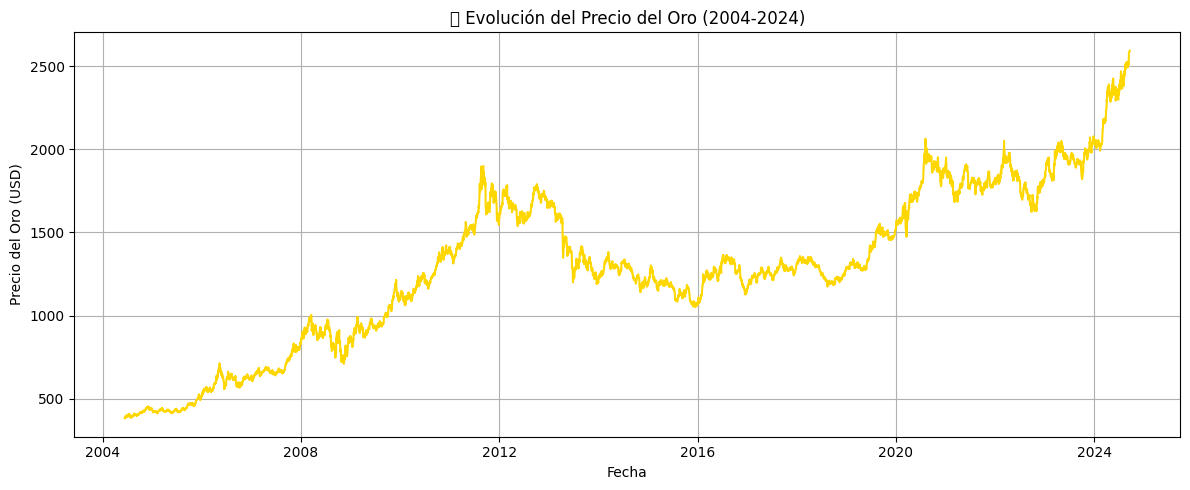

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Precio_Oro'], color='gold')
plt.title("📈 Evolución del Precio del Oro (2004-2024)")
plt.xlabel("Fecha")
plt.ylabel("Precio del Oro (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\3769691754.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


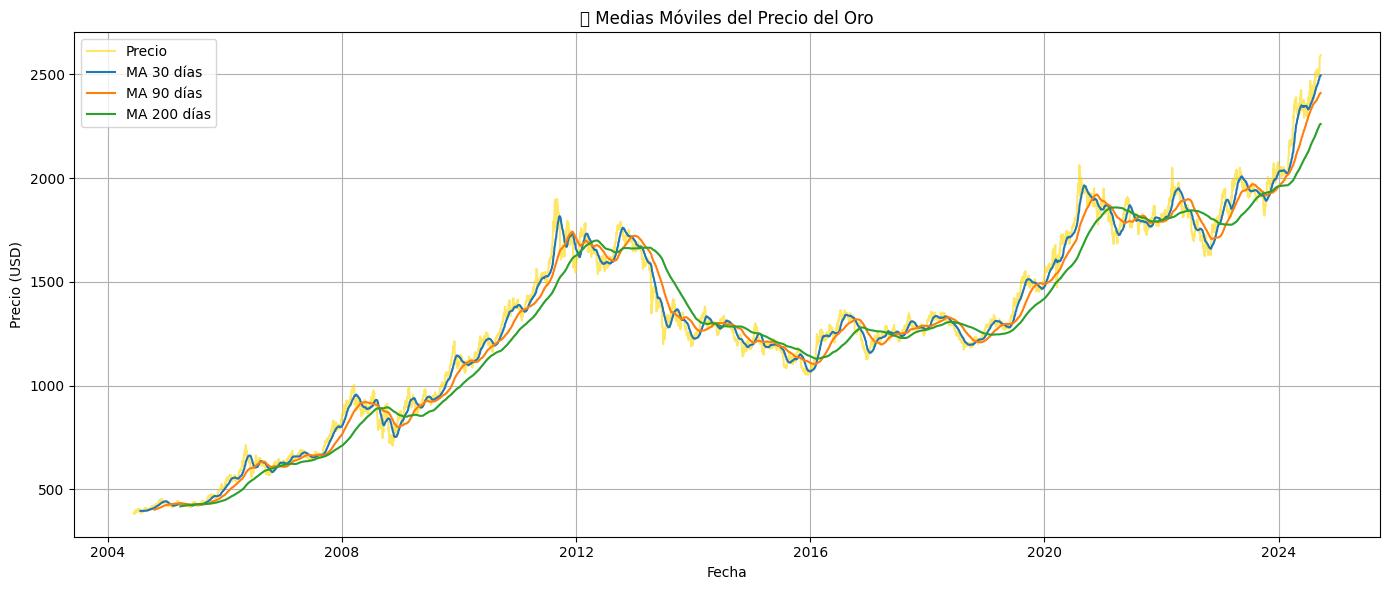

In [8]:
df["MA30"] = df["Precio_Oro"].rolling(window=30).mean()
df["MA90"] = df["Precio_Oro"].rolling(window=90).mean()
df["MA200"] = df["Precio_Oro"].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Precio_Oro"], label="Precio", color="gold", alpha=0.6)
plt.plot(df.index, df["MA30"], label="MA 30 días")
plt.plot(df.index, df["MA90"], label="MA 90 días")
plt.plot(df.index, df["MA200"], label="MA 200 días")
plt.title("📊 Medias Móviles del Precio del Oro")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\1863073109.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  volatilidad_mensual = df["Retorno_Diario"].groupby(pd.Grouper(freq='M')).std() * 100
C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\1863073109.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


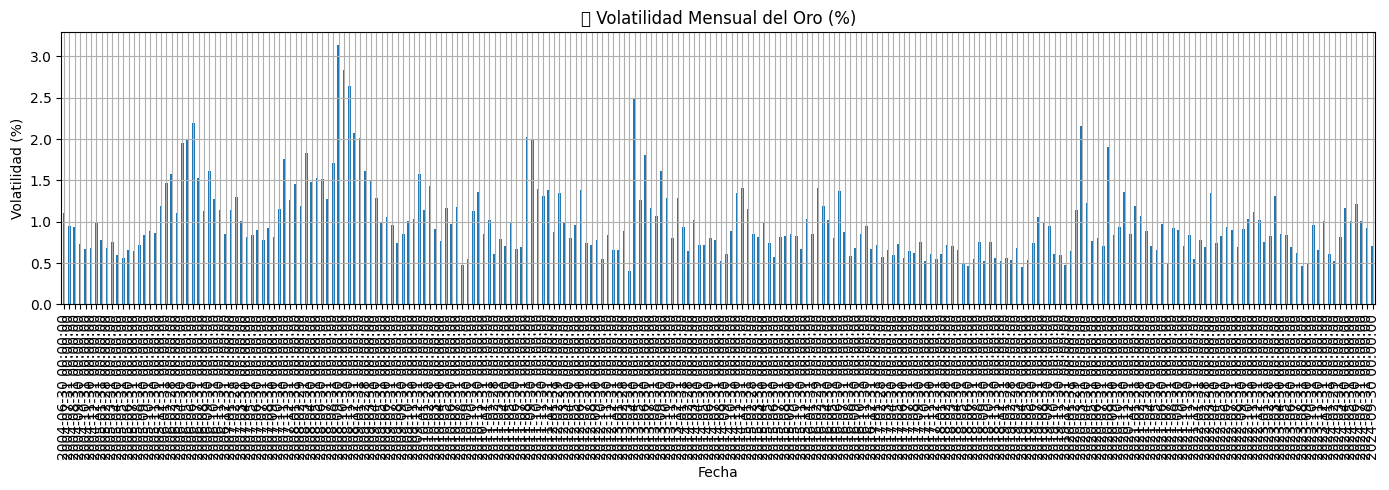

In [9]:
# Calcular retornos diarios
df["Retorno_Diario"] = df["Precio_Oro"].pct_change()

# Agrupar por mes y calcular desviación estándar
volatilidad_mensual = df["Retorno_Diario"].groupby(pd.Grouper(freq='M')).std() * 100

# Graficar
volatilidad_mensual.dropna().plot(kind='bar', figsize=(14, 5), title="📊 Volatilidad Mensual del Oro (%)")
plt.ylabel("Volatilidad (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Asegurar formato correcto de fechas en eventos
eventos_df["Fecha"] = pd.to_datetime(eventos_df["Fecha"])

# Calcular volatilidad 7 días antes y 7 días después de cada evento
impactos = []
for _, row in eventos_df.iterrows():
    fecha = row["Fecha"]
    evento = row["Evento"]
    categoria = row.get("Categoría", "Sin categoría")

    ventana_antes = df[(df.index >= fecha - pd.Timedelta(days=7)) & (df.index < fecha)]
    ventana_despues = df[(df.index > fecha) & (df.index <= fecha + pd.Timedelta(days=7))]

    if not ventana_antes.empty and not ventana_despues.empty:
        vol_antes = ventana_antes["Precio_Oro"].pct_change().std() * 100
        vol_despues = ventana_despues["Precio_Oro"].pct_change().std() * 100

        impactos.append({
            "Evento": evento,
            "Fecha": fecha,
            "Categoría": categoria,
            "Volatilidad Antes (%)": vol_antes,
            "Volatilidad Después (%)": vol_despues
        })

impactos_df = pd.DataFrame(impactos)
print(impactos_df.sort_values("Fecha").head())


                                             Evento      Fecha   Categoría  \
0                        Quiebra de Lehman Brothers 2008-09-15   Económico   
1      Rebaja de calificación crediticia de EE. UU. 2011-08-05  Financiero   
5  Caída abrupta del precio del oro (Crash del oro) 2013-04-12   Económico   
4                             Referéndum del Brexit 2016-06-23    Político   
2                       COVID-19 declarado pandemia 2020-03-11       Salud   

   Volatilidad Antes (%)  Volatilidad Después (%)  
0               2.617631                 5.197325  
1               1.429583                 2.181606  
5               1.060720                 0.278562  
4               1.377536                 0.749409  
2               1.595555                 1.985589  


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\3978552444.py:11: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


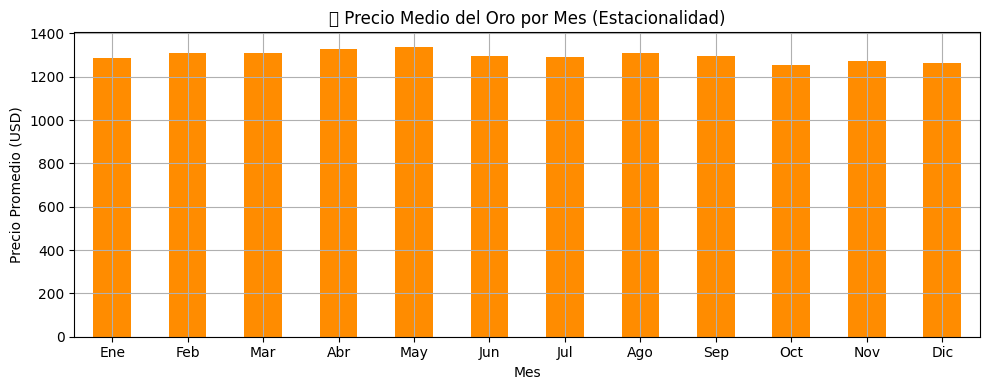

In [11]:
df["Mes"] = df.index.month
precio_medio_mensual = df.groupby("Mes")["Precio_Oro"].mean()

plt.figure(figsize=(10, 4))
precio_medio_mensual.plot(kind="bar", color="darkorange")
plt.title("📆 Precio Medio del Oro por Mes (Estacionalidad)")
plt.xlabel("Mes")
plt.ylabel("Precio Promedio (USD)")
plt.grid(True)
plt.xticks(ticks=range(0, 12), labels=["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"], rotation=0)
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\1612965798.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


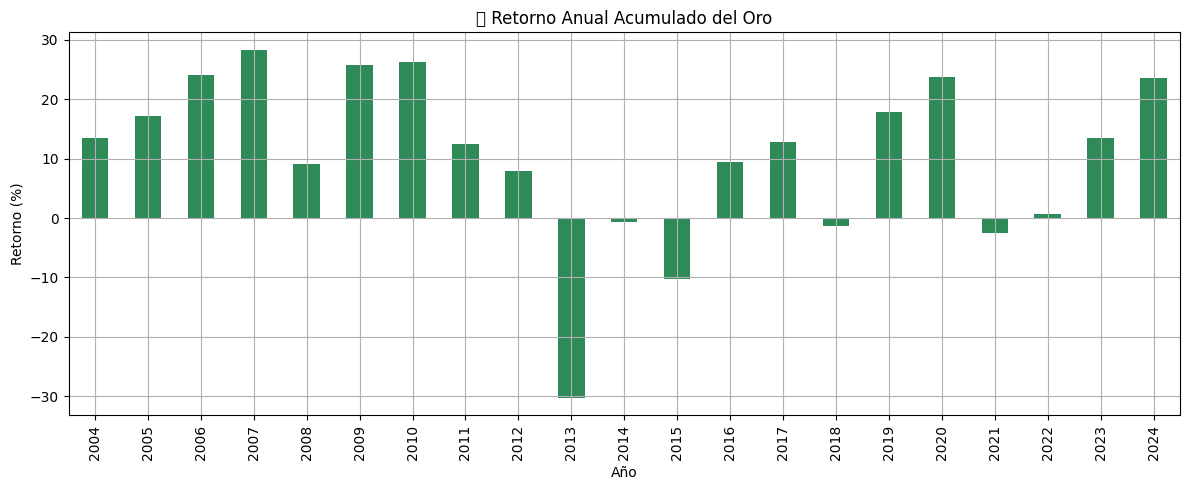

In [12]:
df["Retorno Diario"] = df["Precio_Oro"].pct_change()
df["Año"] = df.index.year
retornos_anuales = df.groupby("Año")["Retorno Diario"].sum() * 100

plt.figure(figsize=(12, 5))
retornos_anuales.plot(kind="bar", color="seagreen")
plt.title("📈 Retorno Anual Acumulado del Oro")
plt.xlabel("Año")
plt.ylabel("Retorno (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
df["Variación %"] = df["Precio_Oro"].pct_change() * 100
top_subidas = df["Variación %"].nlargest(5)
top_bajadas = df["Variación %"].nsmallest(5)

print("📈 Días con mayores subidas del oro:")
print(top_subidas)

print("\n📉 Días con mayores bajadas del oro:")
print(top_bajadas)


📈 Días con mayores subidas del oro:
Fecha
2008-09-17    10.989717
2008-11-21     7.382550
2008-11-04     5.549405
2009-01-23     4.927029
2016-06-24     4.754132
Name: Variación %, dtype: float64

📉 Días con mayores bajadas del oro:
Fecha
2013-04-15   -9.062085
2008-10-10   -6.944140
2006-06-13   -6.405164
2008-12-01   -5.796569
2020-08-11   -5.673675
Name: Variación %, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8016\3551813284.py:8: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


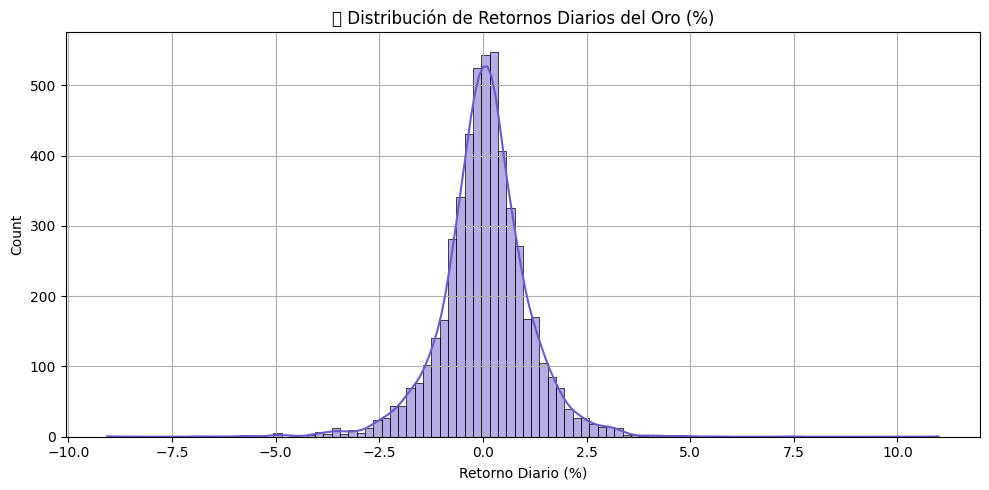

In [14]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["Variación %"].dropna(), bins=100, kde=True, color="slateblue")
plt.title("📊 Distribución de Retornos Diarios del Oro (%)")
plt.xlabel("Retorno Diario (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
# Recalcular retornos si no lo hiciste antes
df["Variación %"] = df["Precio_Oro"].pct_change() * 100
df_variacion = df[["Precio_Oro", "Variación %"]].dropna()

# Obtener top 10 subidas y bajadas
top_dias = pd.concat([
    df_variacion["Variación %"].nlargest(10),
    df_variacion["Variación %"].nsmallest(10)
]).sort_index()

# Buscar eventos ±3 días de esas fechas
resultados = []
for fecha in top_dias.index:
    eventos_cercanos = eventos_df[
        (eventos_df["Fecha"] >= fecha - pd.Timedelta(days=3)) &
        (eventos_df["Fecha"] <= fecha + pd.Timedelta(days=3))
    ]
    for _, evento in eventos_cercanos.iterrows():
        resultados.append({
            "Fecha Precio": fecha.date(),
            "Variación %": df_variacion.loc[fecha, "Variación %"],
            "Evento": evento["Evento"],
            "Fecha Evento": evento["Fecha"].date(),
            "Categoría": evento.get("Categoría", "Sin categoría")
        })

# Mostrar coincidencias
df_coincidencias = pd.DataFrame(resultados)
print(df_coincidencias.sort_values("Fecha Precio"))


  Fecha Precio  Variación %                                            Evento  \
0   2008-09-17    10.989717                        Quiebra de Lehman Brothers   
1   2013-04-12    -5.039110  Caída abrupta del precio del oro (Crash del oro)   
2   2013-04-15    -9.062085  Caída abrupta del precio del oro (Crash del oro)   
3   2016-06-24     4.754132                             Referéndum del Brexit   

  Fecha Evento  Categoría  
0   2008-09-15  Económico  
1   2013-04-12  Económico  
2   2013-04-12  Económico  
3   2016-06-23   Político  


In [16]:
# Días muy volátiles
dias_volatiles = df_variacion[
    (df_variacion["Variación %"].abs() >= 2)
]

# Buscar eventos ocurridos ±2 días
categorias_impacto = []

for fecha in dias_volatiles.index:
    eventos = eventos_df[
        (eventos_df["Fecha"] >= fecha - pd.Timedelta(days=2)) &
        (eventos_df["Fecha"] <= fecha + pd.Timedelta(days=2))
    ]
    for _, e in eventos.iterrows():
        categorias_impacto.append(e.get("Categoría", "Sin categoría"))

# Contar frecuencia por categoría
from collections import Counter
conteo = Counter(categorias_impacto)
for cat, count in conteo.most_common():
    print(f"🗂 {cat}: {count} días con alta volatilidad asociados")


🗂 Económico: 3 días con alta volatilidad asociados
🗂 Salud: 2 días con alta volatilidad asociados
🗂 Político: 1 días con alta volatilidad asociados


In [17]:
# Usamos el cruce de la media móvil de 5 días y 20 días
df["MA5"] = df["Precio_Oro"].rolling(window=5).mean()
df["MA20"] = df["Precio_Oro"].rolling(window=20).mean()
df["Crossover"] = df["MA5"] - df["MA20"]

# Detectar cruces de tendencia
df["Cruzado"] = df["Crossover"].apply(lambda x: 1 if x > 0 else -1)
df["Cambio_Tendencia"] = df["Cruzado"].diff()

# Filtrar cruces
fechas_cambio = df[df["Cambio_Tendencia"].abs() == 2].index

# Buscar eventos ±2 días de cada cruce
cambios_eventos = []
for fecha in fechas_cambio:
    eventos = eventos_df[
        (eventos_df["Fecha"] >= fecha - pd.Timedelta(days=2)) &
        (eventos_df["Fecha"] <= fecha + pd.Timedelta(days=2))
    ]
    for _, evento in eventos.iterrows():
        cambios_eventos.append({
            "Fecha Cambio": fecha.date(),
            "Evento": evento["Evento"],
            "Fecha Evento": evento["Fecha"].date(),
            "Categoría": evento.get("Categoría", "Sin categoría")
        })

df_cambios = pd.DataFrame(cambios_eventos)
print(df_cambios.sort_values("Fecha Cambio"))


  Fecha Cambio                       Evento Fecha Evento Categoría
0   2020-03-13  COVID-19 declarado pandemia   2020-03-11     Salud


In [18]:
# Fusionar eventos con df para ver % de variación en ese día
df_eventos_impacto = df.merge(eventos_df, left_index=True, right_on="Fecha", how="inner")
df_eventos_impacto = df_eventos_impacto[["Fecha", "Evento", "Categoría", "Variación %"]]
df_eventos_impacto["Variación %"] = df_eventos_impacto["Variación %"].round(2)

# Mostrar eventos con impacto fuerte (>2% o <-2%)
impactantes = df_eventos_impacto[df_eventos_impacto["Variación %"].abs() > 2]
print(impactantes.sort_values("Fecha").head(10))


       Fecha                                            Evento  Categoría  \
0 2008-09-15                        Quiebra de Lehman Brothers  Económico   
5 2013-04-12  Caída abrupta del precio del oro (Crash del oro)  Económico   

   Variación %  
0         2.93  
5        -5.04  
